# MindTrack UB - Analysis Pipeline

**AI & Data Innovation Challenge TEKRA 2026**  
**Tema solusi:** Early Warning & Mental Health Risk Monitoring System berbasis AI/Data

Notebook ini dibuat untuk menunjukkan alur berpikir dan pipeline analisis dari data mentah sampai menjadi rancangan solusi berbasis data. Fokusnya bukan sekadar membuat model, tetapi menunjukkan bagaimana data dapat membantu kampus membaca pola risiko kesehatan mental mahasiswa secara lebih awal.

> **Catatan etis:** analisis ini tidak bertujuan memberikan diagnosis medis. Label risiko pada notebook ini hanya pendekatan analitis untuk prototype sistem pendukung keputusan.

## 1. Problem Understanding

### 1.1 Konteks Masalah

Berdasarkan studi kasus, isu utama yang dihadapi adalah meningkatnya tekanan psikologis mahasiswa dalam lingkungan kampus yang sangat besar dan dinamis. Layanan konseling sudah tersedia, tetapi pendekatan yang sangat bergantung pada inisiatif mahasiswa untuk mencari bantuan berpotensi belum cukup untuk menjangkau mahasiswa yang sebenarnya sudah berada dalam kondisi berisiko.

### 1.2 Rumusan Masalah

Masalah yang akan diangkat dalam solusi ini adalah:

> Kampus membutuhkan sistem pendukung keputusan berbasis data untuk membantu mendeteksi pola risiko kesehatan mental mahasiswa lebih awal, membaca treatment gap, dan menentukan prioritas pendampingan secara lebih terstruktur.

### 1.3 Mengapa Data Bisa Membantu?

Data dapat membantu kampus melihat pola yang sulit diamati secara manual, seperti jumlah mahasiswa yang memiliki indikator risiko, kombinasi gejala yang muncul bersamaan, dan apakah mahasiswa dengan indikator risiko sudah mencari bantuan profesional atau belum.

## 2. Import Library dan Setup Project

Bagian ini menyiapkan library yang dibutuhkan, mengatur path project, dan memastikan output visualisasi tersimpan pada folder `outputs/`.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'Student Mental health.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data path exists: {DATA_PATH.exists()}')

Project root: /mnt/data/TEKRA2026_AIData_MindTrackUB
Data path exists: True


## 3. Data Loading & Data Understanding

### 3.1 Load Dataset

Dataset yang digunakan adalah **Student Mental Health Dataset**. Pada tahap ini kita melihat ukuran data, contoh isi data, tipe kolom, dan missing value.

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print(f'Jumlah baris: {raw_df.shape[0]}')
print(f'Jumlah kolom: {raw_df.shape[1]}')
raw_df.head()

Jumlah baris: 101
Jumlah kolom: 11


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


### 3.2 Struktur Kolom

Dari struktur kolom, dataset ini berisi informasi demografis, akademik, indikator kesehatan mental, dan informasi apakah responden mencari bantuan spesialis atau tidak.

In [3]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 non-null    obj

### 3.3 Missing Value dan Nilai Unik

Bagian ini membantu menentukan pembersihan data yang diperlukan. Dataset terlihat sederhana, tetapi masih ada beberapa masalah format seperti spasi ekstra pada CGPA, variasi kapitalisasi pada tahun studi, dan nama course yang tidak konsisten.

In [4]:
missing_summary = raw_df.isna().sum().to_frame('missing_count')
missing_summary['missing_percent'] = (missing_summary['missing_count'] / len(raw_df) * 100).round(2)
missing_summary

,missing_count,missing_percent
Timestamp,0,0.00
Choose your gender,0,0.00
Age,1,0.99
What is your course?,0,0.00
Your current year of Study,0,0.00
What is your CGPA?,0,0.00
Marital status,0,0.00
Do you have Depression?,0,0.00
Do you have Anxiety?,0,0.00
Do you have Panic attack?,0,0.00


In [5]:
for col in raw_df.columns:
    print('\n' + '='*90)
    print(col)
    print(raw_df[col].dropna().astype(str).str.strip().value_counts().head(12))


Timestamp
Timestamp
8/7/2020 12:39    3
8/7/2020 14:29    2
8/7/2020 13:13    2
8/7/2020 12:43    2
8/7/2020 16:34    2
8/7/2020 15:14    2
8/7/2020 14:57    2
8/7/2020 14:43    2
8/7/2020 12:06    1
8/7/2020 12:13    1
8/7/2020 12:32    1
8/7/2020 12:31    1
Name: count, dtype: int64

Choose your gender
Choose your gender
Female    75
Male      26
Name: count, dtype: int64

Age
Age
18.0    32
24.0    23
19.0    21
23.0    13
20.0     6
21.0     3
22.0     2
Name: count, dtype: int64

What is your course?
What is your course?
BCS                   18
Engineering           17
BIT                   10
KOE                    4
Biomedical science     4
Laws                   2
Engine                 2
BENL                   2
Pendidikan Islam       2
psychology             2
KENMS                  1
Irkhs                  1
Name: count, dtype: int64

Your current year of Study
Your current year of Study
year 1    41
Year 3    19
Year 2    16
year 2    10
year 4     8
year 3     5
Year 1  

## 4. Data Cleaning

### 4.1 Tujuan Cleaning

Cleaning dilakukan agar dataset lebih siap dianalisis dan divisualisasikan. Perbaikan utama:

1. Mengubah nama kolom menjadi lebih ringkas.
2. Merapikan kapitalisasi dan spasi.
3. Menyamakan format tahun studi.
4. Mengubah rentang CGPA menjadi nilai midpoint untuk kebutuhan analisis/modeling.
5. Mengubah jawaban Yes/No menjadi format biner.

In [6]:
def normalize_course(course: str) -> str:
    value = str(course).strip().lower()
    value = re.sub(r'\s+', ' ', value)
    mapping = {
        'engin': 'Engineering',
        'engine': 'Engineering',
        'engineering': 'Engineering',
        'mathemathics': 'Mathematics',
        'mathematics': 'Mathematics',
        'pendidikan islam': 'Islamic Education',
        'islamic education': 'Islamic Education',
        'psychology': 'Psychology',
        'law': 'Law',
        'laws': 'Law',
        'benl': 'English Language',
        'enm': 'Engineering',
        'accounting': 'Accounting',
        'accounting ': 'Accounting',
    }
    return mapping.get(value, value.title())


def cgpa_midpoint(cgpa: str) -> float:
    value = str(cgpa).strip()
    numbers = re.findall(r'\d+\.\d+|\d+', value)
    if len(numbers) >= 2:
        low, high = float(numbers[0]), float(numbers[1])
        return round((low + high) / 2, 2)
    return np.nan


def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [col.strip() for col in df.columns]

    rename_map = {
        'Timestamp': 'timestamp',
        'Choose your gender': 'gender',
        'Age': 'age',
        'What is your course?': 'course',
        'Your current year of Study': 'year_of_study',
        'What is your CGPA?': 'cgpa_range',
        'Marital status': 'marital_status',
        'Do you have Depression?': 'depression',
        'Do you have Anxiety?': 'anxiety',
        'Do you have Panic attack?': 'panic_attack',
        'Did you seek any specialist for a treatment?': 'seek_treatment',
    }
    df = df.rename(columns=rename_map)

    text_cols = ['gender', 'course', 'year_of_study', 'cgpa_range', 'marital_status',
                 'depression', 'anxiety', 'panic_attack', 'seek_treatment']
    for col in text_cols:
        df[col] = df[col].astype(str).str.strip()

    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df['gender'] = df['gender'].str.title()
    df['course_clean'] = df['course'].apply(normalize_course)

    df['year_of_study_clean'] = (
        df['year_of_study']
        .str.lower()
        .str.extract(r'(\d)')[0]
        .astype('Int64')
    )
    df['year_label'] = 'Year ' + df['year_of_study_clean'].astype(str)

    df['cgpa_range'] = df['cgpa_range'].str.replace(r'\s+', ' ', regex=True).str.strip()
    df['cgpa_midpoint'] = df['cgpa_range'].apply(cgpa_midpoint)

    df['age'] = df['age'].fillna(df['age'].median())

    yes_no_cols = ['marital_status', 'depression', 'anxiety', 'panic_attack', 'seek_treatment']
    for col in yes_no_cols:
        df[col] = df[col].str.title()
        df[col + '_bin'] = df[col].map({'Yes': 1, 'No': 0})

    return df

clean_df = clean_dataset(raw_df)
clean_df.head()

,timestamp,gender,age,course,year_of_study,cgpa_range,marital_status,depression,anxiety,panic_attack,seek_treatment,course_clean,year_of_study_clean,year_label,cgpa_midpoint,marital_status_bin,depression_bin,anxiety_bin,panic_attack_bin,seek_treatment_bin
0,2020-08-07 12:02:00,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No,Engineering,1,Year 1,3.25,0,1,0,1,0
1,2020-08-07 12:04:00,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No,Islamic Education,2,Year 2,3.25,0,0,1,0,0
2,2020-08-07 12:05:00,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No,Bit,1,Year 1,3.25,0,1,1,1,0
3,2020-08-07 12:06:00,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No,Law,3,Year 3,3.25,1,1,0,0,0
4,2020-08-07 12:13:00,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No,Mathematics,4,Year 4,3.25,0,0,0,0,0


### 4.2 Hasil Setelah Cleaning

Setelah cleaning, dataset memiliki kolom tambahan seperti `course_clean`, `year_label`, `cgpa_midpoint`, dan kolom biner untuk jawaban Yes/No.

In [7]:
clean_df[['gender', 'age', 'course_clean', 'year_label', 'cgpa_range', 'cgpa_midpoint',
          'depression', 'anxiety', 'panic_attack', 'seek_treatment']].head(10)

,gender,age,course_clean,year_label,cgpa_range,cgpa_midpoint,depression,anxiety,panic_attack,seek_treatment
0,Female,18.0,Engineering,Year 1,3.00 - 3.49,3.25,Yes,No,Yes,No
1,Male,21.0,Islamic Education,Year 2,3.00 - 3.49,3.25,No,Yes,No,No
2,Male,19.0,Bit,Year 1,3.00 - 3.49,3.25,Yes,Yes,Yes,No
3,Female,22.0,Law,Year 3,3.00 - 3.49,3.25,Yes,No,No,No
4,Male,23.0,Mathematics,Year 4,3.00 - 3.49,3.25,No,No,No,No
5,Male,19.0,Engineering,Year 2,3.50 - 4.00,3.75,No,No,Yes,No
6,Female,23.0,Islamic Education,Year 2,3.50 - 4.00,3.75,Yes,No,Yes,No
7,Female,18.0,Bcs,Year 1,3.50 - 4.00,3.75,No,Yes,No,No
8,Female,19.0,Human Resources,Year 2,2.50 - 2.99,2.75,No,No,No,No
9,Male,18.0,Irkhs,Year 1,3.50 - 4.00,3.75,No,Yes,Yes,No


## 5. Feature Engineering: Risk Scoring

### 5.1 Alasan Membuat Risk Level

Dataset tidak memiliki kolom risk level secara langsung. Karena itu, dibuat label turunan berbasis tiga indikator yang tersedia:

- `depression`
- `anxiety`
- `panic_attack`

Label ini bukan diagnosis klinis, tetapi pendekatan analitis untuk membantu sistem mengelompokkan tingkat perhatian yang dibutuhkan.

### 5.2 Definisi Risk Level

| Symptom Count | Risk Level | Interpretasi |
|---:|---|---|
| 0 | Low Risk | Tidak ada indikator terdeteksi |
| 1 | Medium Risk | Ada satu indikator, perlu perhatian ringan/lanjutan |
| 2-3 | High Risk | Ada beberapa indikator, perlu prioritas pendampingan |

In [8]:
symptom_cols = ['depression_bin', 'anxiety_bin', 'panic_attack_bin']
clean_df['symptom_count'] = clean_df[symptom_cols].sum(axis=1)
clean_df['risk_level'] = pd.cut(
    clean_df['symptom_count'],
    bins=[-1, 0, 1, 3],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)
clean_df['needs_attention'] = (
    clean_df['risk_level'].isin(['Medium Risk', 'High Risk']) & (clean_df['seek_treatment'] == 'No')
).astype(int)

clean_df[['depression', 'anxiety', 'panic_attack', 'symptom_count', 'risk_level', 'seek_treatment', 'needs_attention']].head(12)

,depression,anxiety,panic_attack,symptom_count,risk_level,seek_treatment,needs_attention
0,Yes,No,Yes,2,High Risk,No,1
1,No,Yes,No,1,Medium Risk,No,1
2,Yes,Yes,Yes,3,High Risk,No,1
3,Yes,No,No,1,Medium Risk,No,1
4,No,No,No,0,Low Risk,No,0
5,No,No,Yes,1,Medium Risk,No,1
6,Yes,No,Yes,2,High Risk,No,1
7,No,Yes,No,1,Medium Risk,No,1
8,No,No,No,0,Low Risk,No,0
9,No,Yes,Yes,2,High Risk,No,1


## 6. Exploratory Data Analysis (EDA)

EDA bertujuan untuk membaca kondisi umum dataset, menemukan pola risiko, dan menghasilkan insight yang bisa dihubungkan dengan rancangan solusi.

### 6.1 Ringkasan Indikator Mental Health

Bagian ini melihat berapa responden yang menjawab Yes pada indikator depression, anxiety, dan panic attack.

In [9]:
indicator_summary = pd.DataFrame({
    'indicator': ['Depression', 'Anxiety', 'Panic Attack'],
    'yes_count': [
        int(clean_df['depression_bin'].sum()),
        int(clean_df['anxiety_bin'].sum()),
        int(clean_df['panic_attack_bin'].sum()),
    ]
})
indicator_summary['yes_percent'] = (indicator_summary['yes_count'] / len(clean_df) * 100).round(1)
indicator_summary

,indicator,yes_count,yes_percent
0,Depression,35,34.7
1,Anxiety,34,33.7
2,Panic Attack,33,32.7


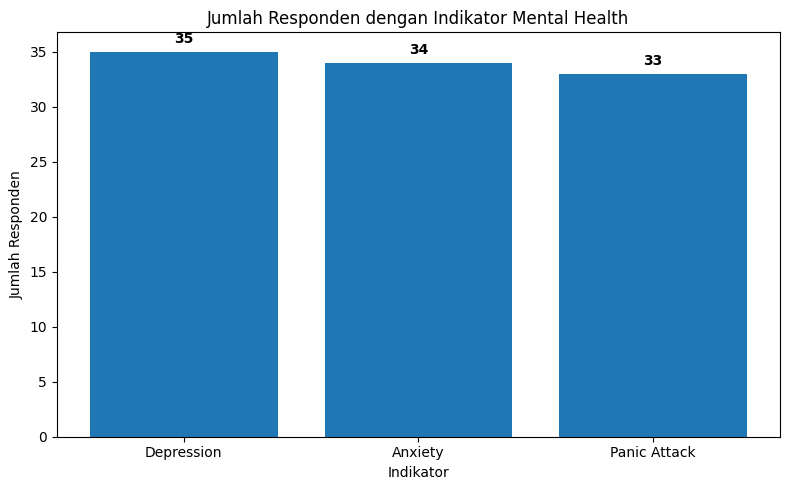

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(indicator_summary['indicator'], indicator_summary['yes_count'])
plt.title('Jumlah Responden dengan Indikator Mental Health')
plt.xlabel('Indikator')
plt.ylabel('Jumlah Responden')
for i, v in enumerate(indicator_summary['yes_count']):
    plt.text(i, v + 0.8, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mental_health_indicators.png', dpi=180, bbox_inches='tight')
plt.show()

### 6.2 Distribusi Risk Level

Risk level membantu mengubah data indikator menjadi kategori yang lebih mudah dipakai untuk pengambilan keputusan.

In [11]:
risk_order = ['Low Risk', 'Medium Risk', 'High Risk']
risk_summary = clean_df['risk_level'].astype(str).value_counts().reindex(risk_order).fillna(0).astype(int).to_frame('count')
risk_summary['percent'] = (risk_summary['count'] / len(clean_df) * 100).round(1)
risk_summary

,count,percent
risk_level,,
Low Risk,37,36.6
Medium Risk,36,35.6
High Risk,28,27.7


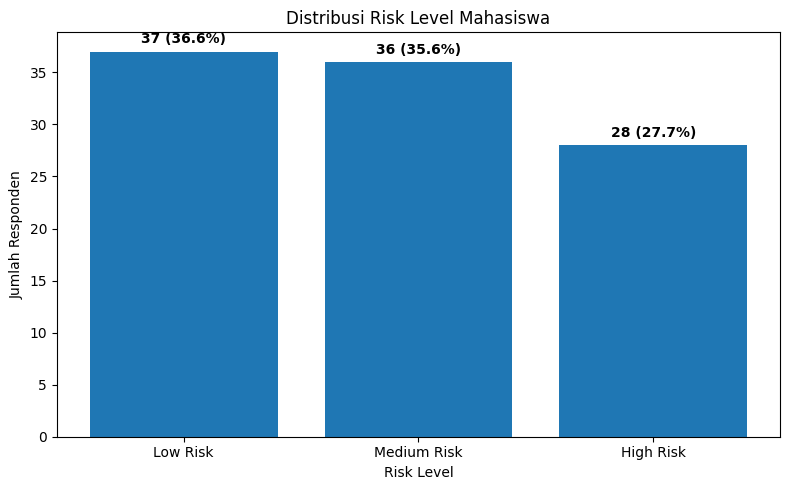

In [12]:
plt.figure(figsize=(8, 5))
bars = plt.bar(risk_summary.index, risk_summary['count'])
plt.title('Distribusi Risk Level Mahasiswa')
plt.xlabel('Risk Level')
plt.ylabel('Jumlah Responden')
for i, v in enumerate(risk_summary['count']):
    plt.text(i, v + 0.8, f'{v} ({risk_summary.iloc[i]["percent"]}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'risk_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

### 6.3 Treatment Gap Analysis

Treatment gap adalah kondisi ketika mahasiswa memiliki indikator risiko tetapi belum mencari bantuan spesialis. Ini penting karena sesuai dengan masalah pada studi kasus: layanan yang mengandalkan inisiatif mahasiswa berpotensi belum menjangkau semua mahasiswa berisiko.

In [13]:
treatment_gap = pd.crosstab(clean_df['risk_level'], clean_df['seek_treatment']).reindex(risk_order)
treatment_gap['total'] = treatment_gap.sum(axis=1)
treatment_gap['not_seeking_percent'] = (treatment_gap.get('No', 0) / treatment_gap['total'] * 100).round(1)
treatment_gap

seek_treatment,No,Yes,total,not_seeking_percent
risk_level,,,,
Low Risk,37,0,37,100.0
Medium Risk,36,0,36,100.0
High Risk,22,6,28,78.6


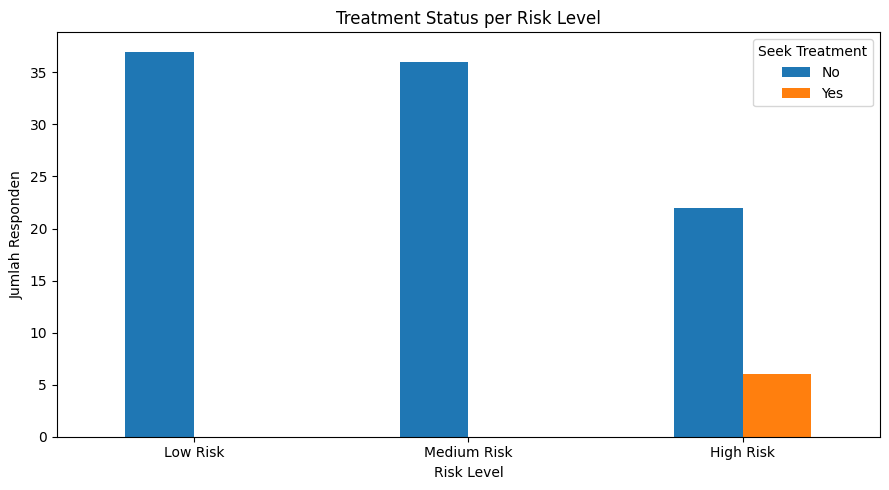

In [14]:
plot_gap = pd.crosstab(clean_df['risk_level'], clean_df['seek_treatment']).reindex(risk_order)
plot_gap.plot(kind='bar', figsize=(9, 5))
plt.title('Treatment Status per Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Jumlah Responden')
plt.xticks(rotation=0)
plt.legend(title='Seek Treatment')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'treatment_gap.png', dpi=180, bbox_inches='tight')
plt.show()

### 6.4 Pola Risiko Berdasarkan Faktor Akademik dan Demografis

Analisis ini tidak digunakan untuk menstigma kelompok tertentu. Tujuannya adalah melihat pola agregat agar kampus dapat menentukan program preventif atau pendampingan yang lebih tepat sasaran.

In [15]:
# Risk level by year of study
risk_by_year = pd.crosstab(clean_df['year_label'], clean_df['risk_level']).reindex(columns=risk_order)
risk_by_year

risk_level,Low Risk,Medium Risk,High Risk
year_label,,,
Year 1,18,12,13
Year 2,7,12,7
Year 3,6,11,7
Year 4,6,1,1


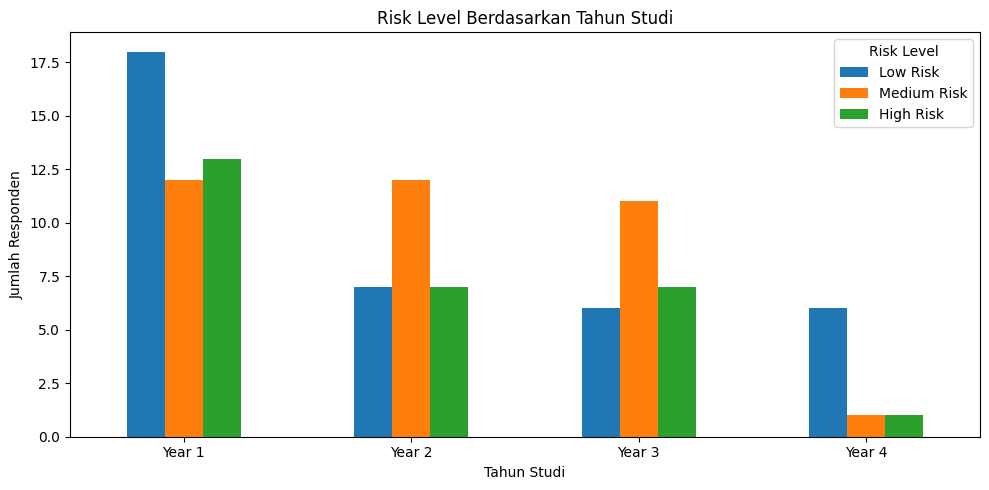

In [16]:
risk_by_year.plot(kind='bar', figsize=(10, 5))
plt.title('Risk Level Berdasarkan Tahun Studi')
plt.xlabel('Tahun Studi')
plt.ylabel('Jumlah Responden')
plt.xticks(rotation=0)
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

In [17]:
# Risk level by CGPA range
risk_by_cgpa = pd.crosstab(clean_df['cgpa_range'], clean_df['risk_level']).reindex(columns=risk_order)
risk_by_cgpa

risk_level,Low Risk,Medium Risk,High Risk
cgpa_range,,,
0 - 1.99,3,1,0
2.00 - 2.49,1,1,0
2.50 - 2.99,1,0,3
3.00 - 3.49,15,17,11
3.50 - 4.00,17,17,14


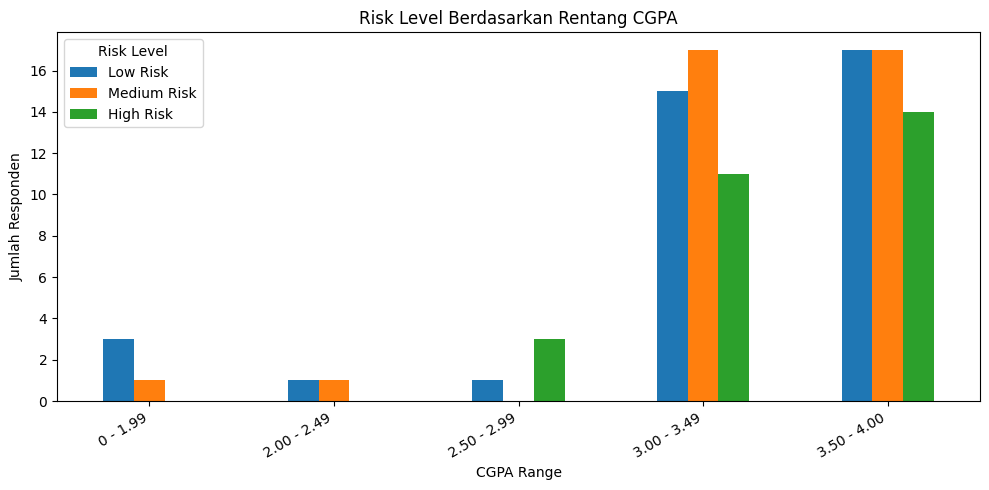

In [18]:
risk_by_cgpa.plot(kind='bar', figsize=(10, 5))
plt.title('Risk Level Berdasarkan Rentang CGPA')
plt.xlabel('CGPA Range')
plt.ylabel('Jumlah Responden')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

## 7. Modeling Prototype

### 7.1 Tujuan Modeling

Modeling pada notebook ini hanya **proof of concept**. Karena dataset kecil, hasil model tidak boleh diposisikan sebagai sistem final. Model digunakan untuk menunjukkan bagaimana pipeline AI dapat dibangun dari data yang tersedia.

### 7.2 Pencegahan Data Leakage

Karena `risk_level` dibuat dari `depression`, `anxiety`, dan `panic_attack`, maka tiga kolom tersebut **tidak digunakan sebagai fitur prediksi**. Jika dipakai, model akan terlihat bagus tetapi sebenarnya hanya membaca jawaban yang membentuk labelnya sendiri.

Fitur yang digunakan:

- gender
- age
- course_clean
- year_label
- cgpa_range
- marital_status

Target:

- risk_level

In [19]:
feature_cols = ['gender', 'age', 'course_clean', 'year_label', 'cgpa_range', 'marital_status']
target_col = 'risk_level'

X = clean_df[feature_cols].copy()
y = clean_df[target_col].astype(str)

categorical_features = ['gender', 'course_clean', 'year_label', 'cgpa_range', 'marital_status']
numeric_features = ['age']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

models = {
    'Baseline - Most Frequent': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    scores = cross_validate(
        pipe, X, y,
        cv=cv,
        scoring=['accuracy', 'f1_macro'],
        return_train_score=False
    )
    results.append({
        'model': name,
        'accuracy_mean': round(scores['test_accuracy'].mean(), 3),
        'accuracy_std': round(scores['test_accuracy'].std(), 3),
        'f1_macro_mean': round(scores['test_f1_macro'].mean(), 3),
        'f1_macro_std': round(scores['test_f1_macro'].std(), 3),
    })

model_results = pd.DataFrame(results).sort_values('f1_macro_mean', ascending=False)
model_results

,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
1,Logistic Regression,0.426,0.143,0.415,0.137
2,Random Forest,0.375,0.158,0.364,0.170
0,Baseline - Most Frequent,0.366,0.021,0.179,0.007


In [20]:
model_results.to_csv(OUTPUT_DIR / 'model_metrics.csv', index=False)

### 7.3 Train/Test Evaluation untuk Model Terpilih

Model terbaik berdasarkan F1-macro diuji lagi pada train/test split. F1-macro dipilih karena target memiliki lebih dari satu kelas dan kita ingin menilai performa rata-rata antar kelas, bukan hanya akurasi total.

In [21]:
best_model_name = model_results.iloc[0]['model']
best_model = models[best_model_name]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

best_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', best_model)])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

print(f'Model terpilih: {best_model_name}')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'F1 Macro: {f1_score(y_test, y_pred, average="macro"):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Model terpilih: Logistic Regression
Accuracy: 0.462
F1 Macro: 0.404

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.43      0.43      0.43         7
    Low Risk       0.50      0.80      0.62        10
 Medium Risk       0.33      0.11      0.17         9

    accuracy                           0.46        26
   macro avg       0.42      0.45      0.40        26
weighted avg       0.42      0.46      0.41        26



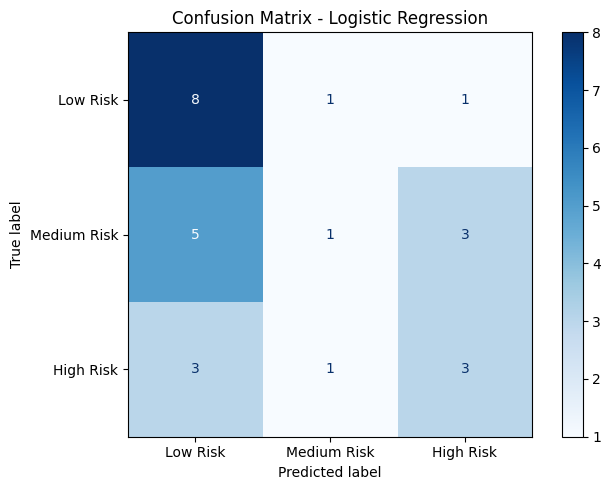

In [22]:
labels = risk_order
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

### 7.4 Interpretasi Modeling

Modeling ini menunjukkan bahwa pipeline AI dapat dibangun, tetapi dataset masih terlalu kecil untuk menghasilkan model yang siap dipakai pada kondisi nyata. Karena itu, pada solusi akhir, model diposisikan sebagai **prototype** dan decision support lebih ditekankan pada:

1. Risk scoring yang transparan.
2. Dashboard analitik.
3. Treatment gap analysis.
4. Rekomendasi tindak lanjut.
5. Human review oleh konselor/pihak kampus.

## 8. Decision Support Design

### 8.1 Cara Sistem Membantu Kampus Mengambil Keputusan

Sistem ini mendukung keputusan dengan cara:

1. Mengubah data mentah menjadi indikator risiko.
2. Mengelompokkan mahasiswa ke level risiko.
3. Menampilkan pola risiko secara agregat.
4. Mengidentifikasi mahasiswa/kelompok yang berisiko tetapi belum mencari bantuan.
5. Memberikan rekomendasi tindak lanjut sesuai risk level.

### 8.2 Mapping Rekomendasi Bantuan

| Risk Level | Bantuan yang Disarankan | Tujuan |
|---|---|---|
| Low Risk | Edukasi mental health, artikel self-care, reminder layanan konseling | Pencegahan dan literasi |
| Medium Risk | Self-assessment lanjutan, peer counselor, konseling ringan, konsultasi akademik | Intervensi awal |
| High Risk | Prioritas outreach konselor, jadwal konseling profesional, monitoring berkala, rujukan bila perlu | Pendampingan intensif |

### 8.3 Prinsip Etis

- Sistem tidak boleh digunakan untuk diagnosis.
- Data sensitif harus dilindungi.
- Hasil harus ditinjau manusia.
- Sistem tidak boleh menstigma mahasiswa.
- Implementasi nyata membutuhkan persetujuan etik dan tata kelola data.

## 9. Export Data untuk Dashboard

Data yang sudah diproses diekspor agar dapat langsung digunakan oleh dashboard Streamlit.

In [23]:
processed_path = OUTPUT_DIR / 'processed_student_mental_health.csv'
clean_df.to_csv(processed_path, index=False)
print(f'Processed data saved to: {processed_path}')

# Membuat ringkasan kecil yang bisa dipakai pada dokumen/presentasi
summary = {
    'total_respondents': len(clean_df),
    'depression_yes': int(clean_df['depression_bin'].sum()),
    'anxiety_yes': int(clean_df['anxiety_bin'].sum()),
    'panic_attack_yes': int(clean_df['panic_attack_bin'].sum()),
    'any_symptom': int((clean_df['symptom_count'] >= 1).sum()),
    'seek_treatment_yes': int(clean_df['seek_treatment_bin'].sum()),
    'low_risk': int((clean_df['risk_level'].astype(str) == 'Low Risk').sum()),
    'medium_risk': int((clean_df['risk_level'].astype(str) == 'Medium Risk').sum()),
    'high_risk': int((clean_df['risk_level'].astype(str) == 'High Risk').sum()),
    'needs_attention': int(clean_df['needs_attention'].sum()),
}
pd.Series(summary).to_frame('value')

Processed data saved to: /mnt/data/TEKRA2026_AIData_MindTrackUB/outputs/processed_student_mental_health.csv


,value
total_respondents,101
depression_yes,35
anxiety_yes,34
panic_attack_yes,33
any_symptom,64
seek_treatment_yes,6
low_risk,37
medium_risk,36
high_risk,28
needs_attention,58


## 10. Membuat Preview Dashboard

Preview ini berupa gambar ringkas untuk menunjukkan konsep tampilan dashboard yang akan dibuat menggunakan Streamlit.

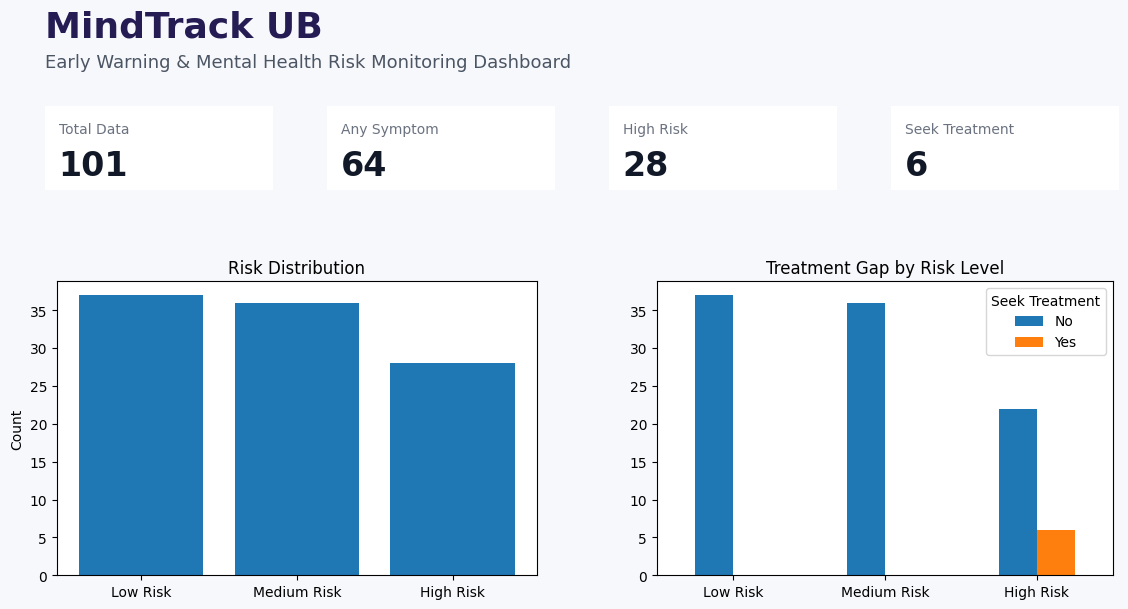

In [24]:
# Simple static preview image for documentation purposes
fig = plt.figure(figsize=(12, 7))
fig.patch.set_facecolor('#F7F8FC')

plt.figtext(0.05, 0.92, 'MindTrack UB', fontsize=26, fontweight='bold', color='#251C54')
plt.figtext(0.05, 0.875, 'Early Warning & Mental Health Risk Monitoring Dashboard', fontsize=13, color='#4B5563')

cards = [
    ('Total Data', str(summary['total_respondents'])),
    ('Any Symptom', str(summary['any_symptom'])),
    ('High Risk', str(summary['high_risk'])),
    ('Seek Treatment', str(summary['seek_treatment_yes'])),
]
x0s = [0.05, 0.285, 0.52, 0.755]
for x0, (label, value) in zip(x0s, cards):
    ax = fig.add_axes([x0, 0.70, 0.19, 0.12])
    ax.set_facecolor('white')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.text(0.06, 0.68, label, fontsize=10, color='#6B7280', transform=ax.transAxes)
    ax.text(0.06, 0.18, value, fontsize=24, fontweight='bold', color='#111827', transform=ax.transAxes)

ax1 = fig.add_axes([0.06, 0.15, 0.40, 0.42])
ax1.bar(risk_summary.index, risk_summary['count'])
ax1.set_title('Risk Distribution')
ax1.set_ylabel('Count')

ax2 = fig.add_axes([0.56, 0.15, 0.38, 0.42])
plot_gap[['No', 'Yes']].plot(kind='bar', ax=ax2)
ax2.set_title('Treatment Gap by Risk Level')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title='Seek Treatment')

plt.savefig(OUTPUT_DIR / 'dashboard_preview.png', dpi=180, bbox_inches='tight')
plt.show()

## 11. Kesimpulan Analisis

Dari analisis ini, solusi **MindTrack UB** cocok karena menjawab masalah utama pada studi kasus: bagaimana kampus dapat mendeteksi risiko kesehatan mental mahasiswa secara lebih awal dalam skala besar.

Insight kunci:

1. Dataset dapat digunakan untuk membuat risk scoring awal berbasis depression, anxiety, dan panic attack.
2. Treatment gap menjadi argumen kuat bahwa layanan yang menunggu inisiatif mahasiswa saja belum cukup.
3. Dashboard analitik membuat pola risiko lebih mudah dibaca oleh pengambil keputusan.
4. Model AI dapat dibuat sebagai proof of concept, tetapi tidak boleh menjadi satu-satunya dasar keputusan.
5. Solusi harus tetap menjaga privasi, menghindari stigma, dan melibatkan konselor dalam keputusan akhir.